
Mask applied with threshold 24 on cosmos_subaru_b_true. Number of galaxies after masking: 381805

Selecting top 0 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 0
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 379789

Selecting top 70 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 737
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 379095

Selecting top 100 GW events for follow-up based on sky area.
Total galaxies with spec-z error 0.001 and 19.5 < r < 22: 1240
Total galaxies with spec-z error 0.001 and r < 19.5: 2016
Total galaxies with photo-z error 0.05: 378624

Total sky area covered by top 70 GW events: 95.2892030606115 deg^2


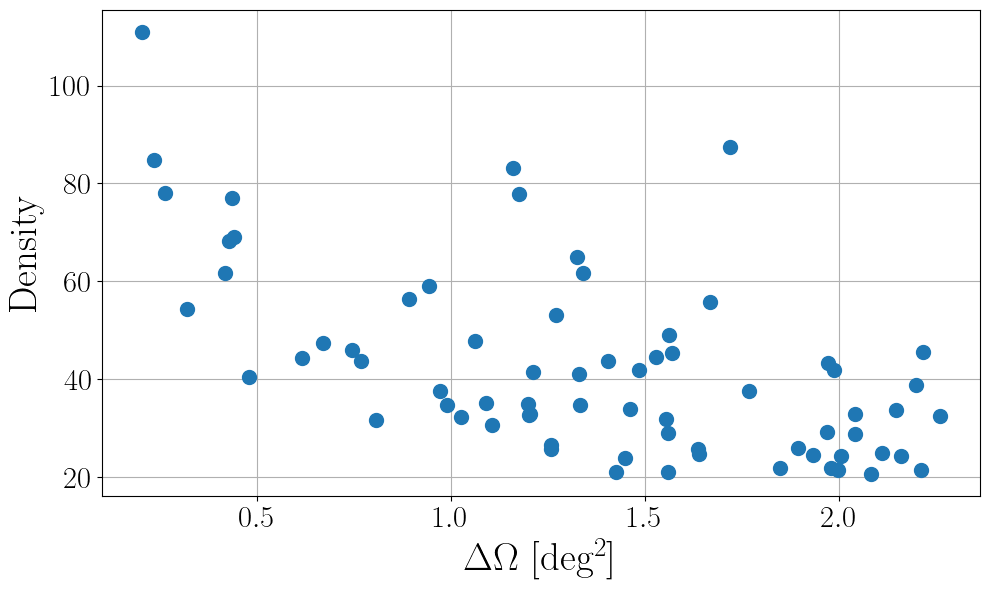

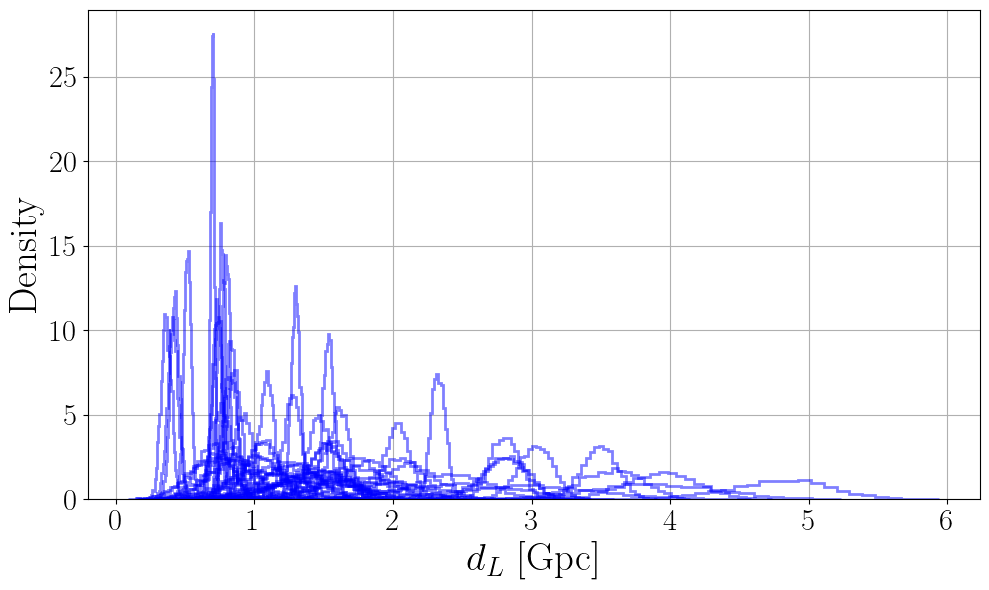

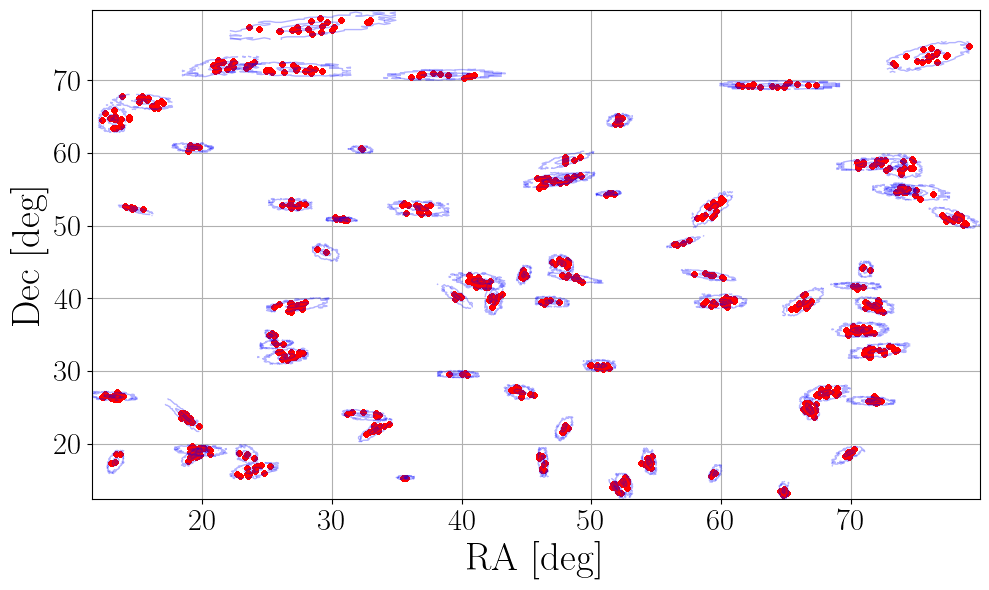

In [19]:
from CHIMERA.cosmo import flrw
from CHIMERA.mass import plp
from CHIMERA.rate import madau_dickinson
from CHIMERA.catalog import dVdz_completeness, pixelated_catalog, mask_completeness
from CHIMERA import population, compute_z_grids
from CHIMERA import data as data
import h5py
import numpy as np
import jax.numpy as jnp
from astropy.cosmology import FlatLambdaCDM
from CHIMERA import utils
import healpy as hp
import matplotlib.pyplot as plt

"""GW data"""
fpe = "./data/PE_O5Like_snr20.h5"
f_gw_pix = './data/PE_O5Like_snr20_pixelated_nsidelist512-256-128-64-32-16-8_meanpixels15_skyconf0.9_nestFalse.h5'
gw_pe_det_pixelated = data.load_pixelated_gw_catalog(f_gw_pix)

"""fiducial cosmology"""
cosmo = flrw(
            H0 = 70., 
            Om0=0.25,
            z_max = 5.
            )

z_grids = compute_z_grids(cosmo, 
                          gw_pe_det_pixelated, 
                          cosmo_prior = {'H0':[20,200]}, 
                          z_int_res = 500,)

"""galaxy catalog"""
fname_gal = "./data/parent_galaxy_catalog_1.6M_dVdz.h5"

mask_str = 'cosmos_subaru_b_true'
photo_thresholds = 24
spec_default_thresholds = 19.5
spec_subaru_thresholds = 22
with h5py.File(fname_gal, "r") as f:
    mask_photo = f[mask_str][:]<=photo_thresholds
    mask_spec_default = f[mask_str][:]<=spec_default_thresholds
    mask_spec_subaru = f[mask_str][:]<=spec_subaru_thresholds

    z_gal = f['z_cgal'][:]
    
    ra_gal_raw = f['ra_gal'][:]
    dec_gal_raw = f['dec_gal'][:]
    
    phi_gal = np.radians(ra_gal_raw)
    theta_gal = np.radians(90.0 - dec_gal_raw)
    
    ra_gal_deg = (ra_gal_raw + 180) % 360 - 180
    dec_gal_deg = dec_gal_raw
    ra_gal_rad = np.deg2rad(ra_gal_deg)
    dec_gal_rad = np.deg2rad(dec_gal_deg)
print(f"\nMask applied with threshold {photo_thresholds} on {mask_str}. Number of galaxies after masking: {np.sum(mask_photo)}")

photo_err = 0.05
spec_err = 0.001

"""select follow up event"""
gw_opt_nsides = gw_pe_det_pixelated.opt_nsides
gw_pixels_opt_nsides = gw_pe_det_pixelated.pixels_opt_nsides
# print(f"GW pixelated catalog loaded with NSIDE values: {gw_opt_nsides}")
# print(f"GW pixelated catalog loaded with pixelated NSIDE values: {gw_pixels_opt_nsides}")

GW_properties = utils.io.load_data_h5(fpe, group_h5='properties')
gw_sky_area = GW_properties['sky_area']
gw_snr = GW_properties['snr']

num_follow_up_events_list = [0, 70, 100]
gw_index_list = []
gal_index_gw_and_subaru_list = []
gal_index_gw_and_default_list = []
z_err_array_list = []
for num_follow_up_events in num_follow_up_events_list:
    print(f"\nSelecting top {num_follow_up_events} GW events for follow-up based on sky area.")
    
    z_err_array = np.zeros_like(z_gal)
    z_err_array[mask_photo] = photo_err
    z_err_array[mask_spec_default] = spec_err

    is_in_gw_area_total = np.zeros_like(z_gal, dtype=bool)
    if num_follow_up_events > 0:
        best_sky_area_indices = np.argsort(gw_sky_area)[:num_follow_up_events]
        target_gw_indices = best_sky_area_indices

        ev_nsides_array = gw_opt_nsides[target_gw_indices]
        ev_pixels_array = gw_pixels_opt_nsides[target_gw_indices]

        for idx, (nside, pixels) in enumerate(zip(ev_nsides_array, ev_pixels_array)):
            valid_pixels = pixels[pixels >= 0]
            gal_pixel_ids = hp.ang2pix(nside, theta_gal, phi_gal, nest=False)
            is_in_gw_area_total |= np.isin(gal_pixel_ids, valid_pixels)
            # print(f"GW event {target_gw_indices[idx]}: {np.sum(is_in_gw_area_total)} galaxies to spec-z with error {spec_err}.")

        z_err_array[is_in_gw_area_total & mask_spec_subaru] = spec_err
    z_err_array_list.append(z_err_array)
    print(f"Total galaxies with spec-z error {spec_err} and {spec_default_thresholds} < r < {spec_subaru_thresholds}: {np.sum(is_in_gw_area_total & mask_spec_subaru)}")
    print(f"Total galaxies with spec-z error {spec_err} and r < {spec_default_thresholds}: {np.sum(mask_spec_default)}")
    print(f"Total galaxies with photo-z error {photo_err}: {np.sum(z_err_array == photo_err)}")
    gw_index_list.append(target_gw_indices if num_follow_up_events > 0 else "None")
    gal_index_gw_and_subaru_list.append(is_in_gw_area_total & mask_spec_subaru)
    gal_index_gw_and_default_list.append(is_in_gw_area_total & mask_spec_default)


gw_pe_det = data.load_gw_pe_samples(fpe, parameters=['m1det', 'm2det', 'dL', 'ra', 'dec', 'phi', 'theta'])
gw_pe_det = gw_pe_det.update(pe_prior=gw_pe_det.dL**2)

GW_properties = utils.io.load_data_h5(fpe, group_h5='properties')
gw_sky_area = GW_properties['sky_area']
gw_snr = GW_properties['snr']

best_sky_area_indices = np.argsort(gw_sky_area)[:num_follow_up_events_list[1]]
sky_area = gw_sky_area[best_sky_area_indices]
print(f"\nTotal sky area covered by top {num_follow_up_events_list[1]} GW events: {np.sum(sky_area)} deg^2")

snr = gw_snr[best_sky_area_indices]
dL_pos = gw_pe_det.dL[best_sky_area_indices]
ra_pos = gw_pe_det.ra[best_sky_area_indices]
dec_pos = gw_pe_det.dec[best_sky_area_indices]

plt.style.use('~/research/my_plot_style.style')
plt.figure()
plt.scatter(sky_area, snr, s=100, label=f'GW events')
plt.xlabel(r'$\Delta\Omega$~[deg$^{2}$]')
plt.ylabel('Density')
plt.show()

plt.figure()
for dL_pos in dL_pos:
    plt.hist(dL_pos, bins=30, density=True, alpha=0.5, color='blue', histtype='step', lw=2)
plt.xlabel(r'$d_{L}$~[Gpc]')
plt.ylabel('Density')
plt.show()


gal_ra_gw_area_r_default, gal_dec_gw_area_r_default = ra_gal_deg[gal_index_gw_and_default_list[1]], dec_gal_deg[gal_index_gw_and_default_list[1]]
gal_ra_gw_area_and_subaru, gal_dec_gw_area_and_subaru = ra_gal_deg[gal_index_gw_and_subaru_list[1]], dec_gal_deg[gal_index_gw_and_subaru_list[1]]

plt.figure()
for ra_pos, dec_pos in zip(ra_pos, dec_pos):
    counts, xedges, yedges = np.histogram2d(ra_pos * 180 / np.pi, dec_pos * 180 / np.pi, bins=30, density=True)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(xcenters, ycenters)    
    plt.contour(X, Y, counts.T, levels=2, alpha=0.3, linewidths=1, colors='blue')
    # plt.scatter(gal_ra_gw_area_r_default, gal_dec_gw_area_r_default, s=10, color='orange', label='Galaxies with spec-z (r < 19.5)', alpha=0.8)
    plt.scatter(gal_ra_gw_area_and_subaru, gal_dec_gw_area_and_subaru, s=10, color='red', label='Galaxies with spec-z (r < 22)', alpha=0.8)
plt.xlabel(r'RA~[deg]')
plt.ylabel(r'Dec~[deg]')
# plt.legend()
plt.show()
